# Ejemplo de Gaussian Mixture Model (GMM) con el dataset Wine

## Objetivos

En este notebook utilizaremos el dataset Wine de `scikit-learn` para:

1. cargar y explorar brevemente los datos;
2. analizar la distribución de las variables y seleccionar Pearson o Spearman para el análisis de correlación;
3. estandarizar las variables;
4. aplicar un modelo de mezclas gaussianas (GMM);
5. comparar diferentes números de componentes y estructuras de covarianza;
6. utilizar AIC y BIC para apoyar la selección del modelo;
7. evaluar las particiones mediante Silhouette, Davies-Bouldin y Calinski-Harabasz;
8. analizar las probabilidades de pertenencia o responsabilidades;
9. visualizar e interpretar los clusters encontrados;
10. comparar al final con las clases reales como evaluación externa.

## 1. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)
from scipy.stats import shapiro

pd.set_option("display.max_columns", None)

from sklearn.mixture import GaussianMixture

## 2. Carga del dataset

`load_wine()` contiene 178 observaciones, 13 características químicas numéricas y tres clases reales. Durante el ajuste de GMM trabajaremos únicamente con $X$.

In [2]:
wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="target")

print("Dimensiones de X:", X.shape)
print("Número de clases reales:", y.nunique())
X.head()

Dimensiones de X: (178, 13)
Número de clases reales: 3


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## 3. Exploración inicial

Revisaremos valores faltantes, estadísticos descriptivos, diferencias de escala, distribución y correlaciones antes de ajustar el modelo.

In [3]:
print("Valores faltantes por variable:")
display(X.isna().sum().to_frame("faltantes"))

print("\nEstadísticos descriptivos:")
display(X.describe().T)

Valores faltantes por variable:


,faltantes
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0



Estadísticos descriptivos:


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


### 3.1. Comparación de escalas

In [4]:
ranges = pd.DataFrame({
    "min": X.min(),
    "max": X.max(),
    "rango": X.max() - X.min(),
    "media": X.mean(),
    "std": X.std()
}).sort_values("rango", ascending=False)

ranges

,min,max,rango,media,std
proline,278.00,1680.00,1402.00,746.893258,314.907474
magnesium,70.00,162.00,92.00,99.741573,14.282484
alcalinity_of_ash,10.60,30.00,19.40,19.494944,3.339564
color_intensity,1.28,13.00,11.72,5.058090,2.318286
malic_acid,0.74,5.80,5.06,2.336348,1.117146
flavanoids,0.34,5.08,4.74,2.029270,0.998859
alcohol,11.03,14.83,3.80,13.000618,0.811827
proanthocyanins,0.41,3.58,3.17,1.590899,0.572359
total_phenols,0.98,3.88,2.90,2.295112,0.625851
od280/od315_of_diluted_wines,1.27,4.00,2.73,2.611685,0.709990


Las variables presentan escalas muy diferentes. Aunque GMM modela medias y covarianzas, la estandarización facilita la comparación entre variables y mejora la estabilidad numérica del ajuste.

### 3.2. Distribución de las variables: decisión entre Pearson y Spearman

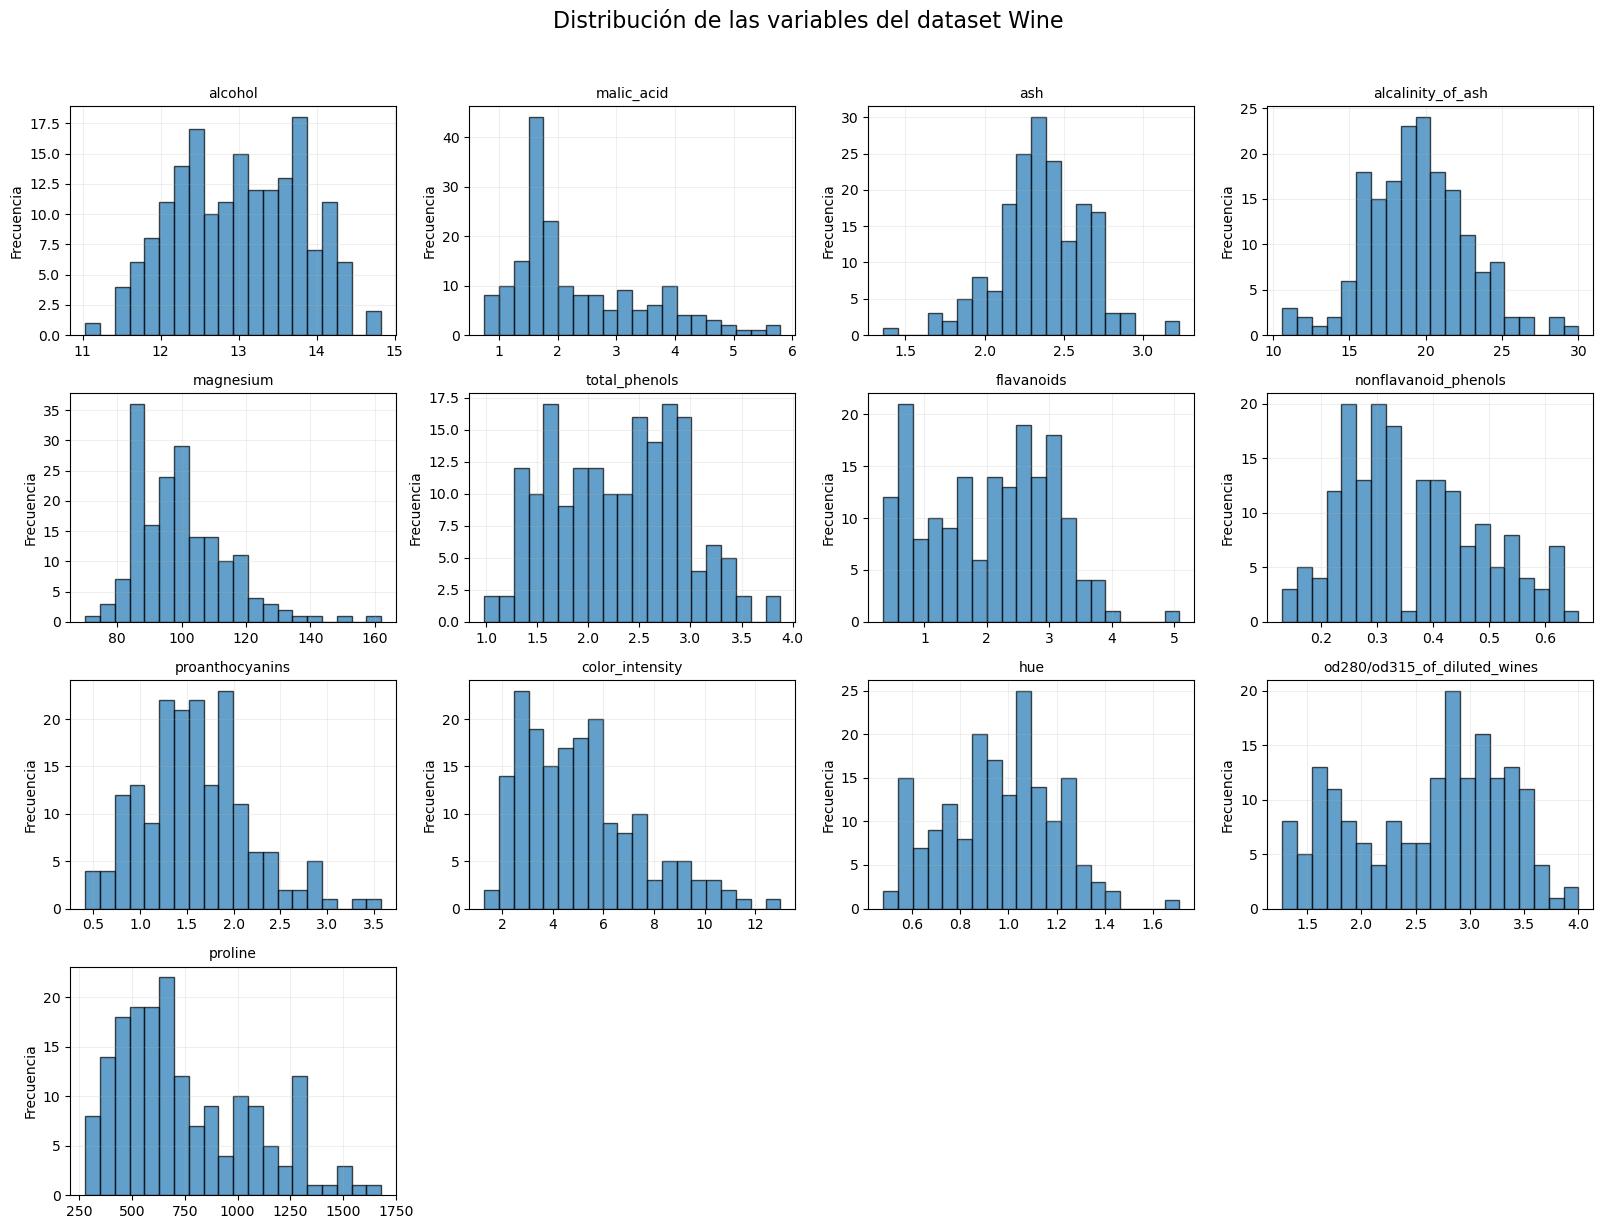

In [5]:
# Variables numéricas del dataset
features = X.columns

n_cols = 4
n_rows = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(X[col], bins=20, edgecolor="black", alpha=0.7)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frecuencia")
    axes[i].grid(alpha=0.2)

# Ocultar subplots sobrantes
for j in range(len(features), len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Distribución de las variables del dataset Wine",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

In [6]:
normality_rows = []

for variable in X.columns:
    stat, p_value = shapiro(X[variable])
    normality_rows.append({
        "variable": variable,
        "W": stat,
        "p_value": p_value,
        "¿No se rechaza normalidad?": p_value >= 0.05
    })

normality = pd.DataFrame(normality_rows).set_index("variable")
normality.round(4)

,W,p_value,¿No se rechaza normalidad?
variable,,,
alcohol,0.9818,0.0200,False
malic_acid,0.8888,0.0000,False
ash,0.9839,0.0387,False
alcalinity_of_ash,0.9902,0.2639,True
magnesium,0.9383,0.0000,False
total_phenols,0.9767,0.0044,False
flavanoids,0.9545,0.0000,False
nonflavanoid_phenols,0.9625,0.0001,False
proanthocyanins,0.9807,0.0145,False


Con $\alpha=0.05$, la gran mayoría de variables del Wine rechaza normalidad individual. Por ello, para el análisis exploratorio utilizaremos **Spearman**. Esto no impide utilizar GMM: el supuesto gaussiano del GMM se refiere a la distribución **multivariada dentro de cada componente**, no a que cada variable marginal del dataset completo deba ser normal.

Método de correlación seleccionado: Spearman
Variables que no rechazan normalidad: 1 de 13


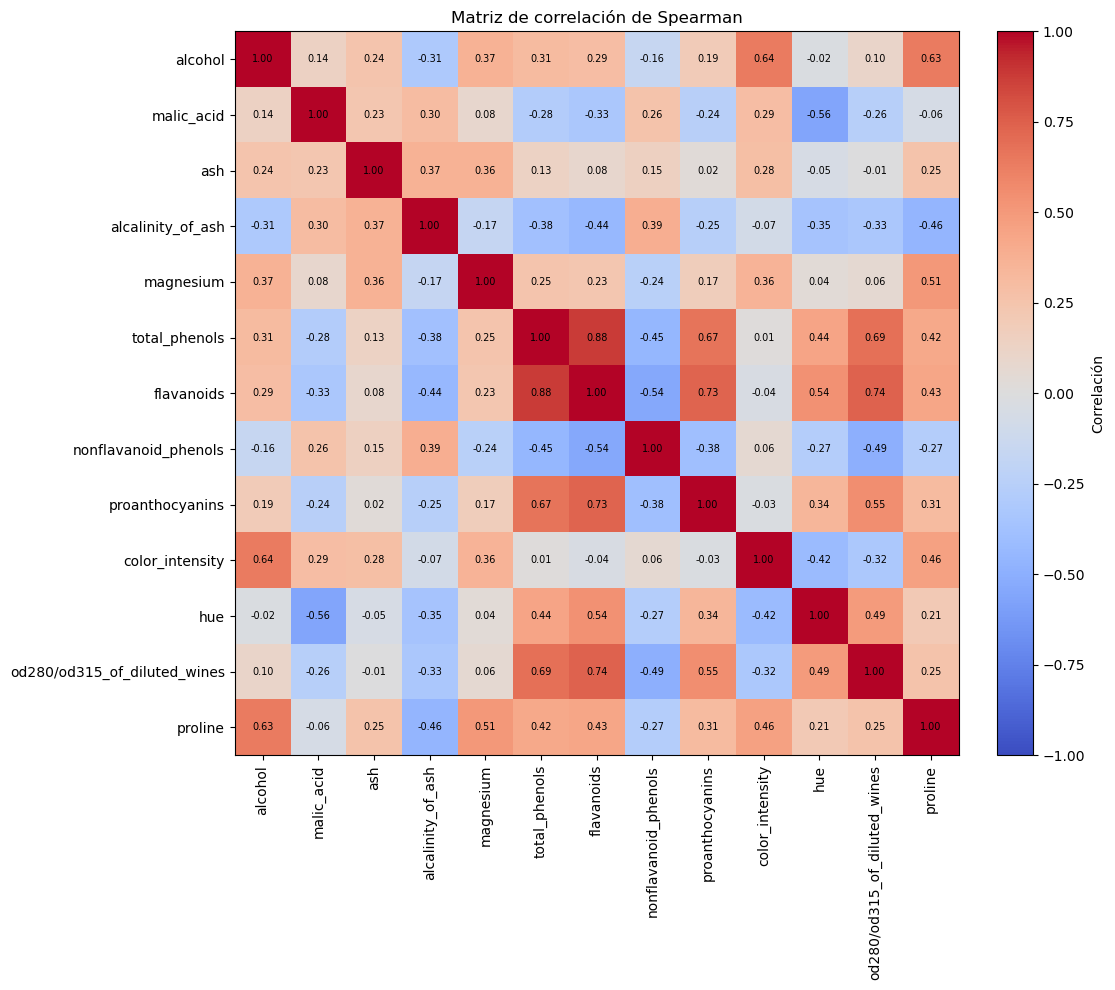

In [7]:
# Regla didáctica para este EDA:
# - Pearson si todas las variables no rechazan normalidad a alpha=0.05.
# - Spearman si al menos una variable presenta evidencia de no normalidad.
# En Wine, la gran mayoría rechaza normalidad, por lo que se utiliza Spearman.

all_normal = normality["¿No se rechaza normalidad?"].all()
corr_method = "pearson" if all_normal else "spearman"

print("Método de correlación seleccionado:", corr_method.capitalize())
print(
    "Variables que no rechazan normalidad:",
    int(normality["¿No se rechaza normalidad?"].sum()),
    "de", X.shape[1]
)

corr = X.corr(method=corr_method)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Correlación")
ax.set_title(f"Matriz de correlación de {corr_method.capitalize()}")
plt.tight_layout()
plt.show()

### 3.3. Pares de variables con mayor correlación absoluta

In [8]:
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
strong_pairs = (
    upper.stack()
         .rename("correlacion")
         .reset_index()
         .rename(columns={"level_0": "variable_1", "level_1": "variable_2"})
)
strong_pairs["abs_correlacion"] = strong_pairs["correlacion"].abs()
strong_pairs = strong_pairs.sort_values("abs_correlacion", ascending=False)
strong_pairs.head(10).drop(columns="abs_correlacion").round(3)

,variable_1,variable_2,correlacion
50,total_phenols,flavanoids,0.879
61,flavanoids,od280/od315_of_diluted_wines,0.742
58,flavanoids,proanthocyanins,0.730
55,total_phenols,od280/od315_of_diluted_wines,0.687
52,total_phenols,proanthocyanins,0.667
8,alcohol,color_intensity,0.635
11,alcohol,proline,0.634
20,malic_acid,hue,-0.560
70,proanthocyanins,od280/od315_of_diluted_wines,0.554
57,flavanoids,nonflavanoid_phenols,-0.544


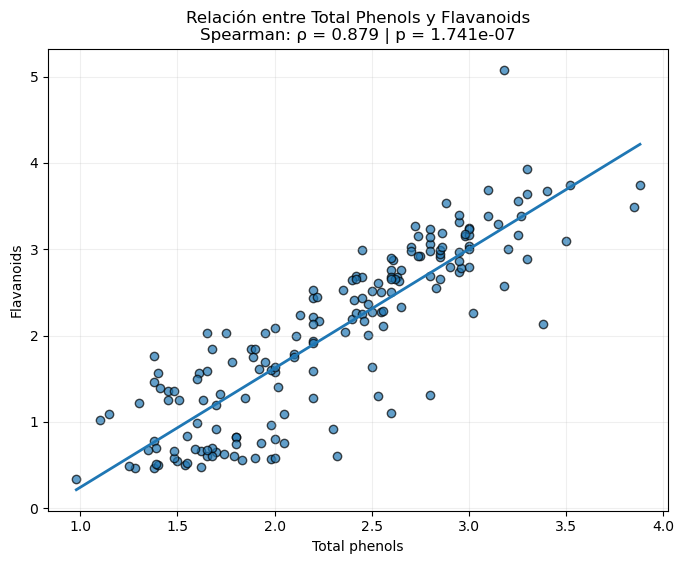

In [9]:
var1 = "total_phenols"
var2 = "flavanoids"
method = "Spearman"
symbol = "ρ"
corr_value = strong_pairs.loc[((strong_pairs["variable_1"] == var1) & (strong_pairs["variable_2"] == var2)) |
    ((strong_pairs["variable_1"] == var2) & (strong_pairs["variable_2"] == var1)), "correlacion" ].iloc[0]

plt.figure(figsize=(8, 6))

plt.scatter(X[var1], X[var2], alpha=0.7, edgecolor="black")

m, b = np.polyfit(X[var1], X[var2], 1)

x_line = np.linspace(X[var1].min(), X[var1].max(), 100)
y_line = m * x_line + b

plt.plot(x_line, y_line, linewidth=2, label="Tendencia lineal")

plt.xlabel("Total phenols")
plt.ylabel("Flavanoids")

plt.title(
    f"Relación entre Total Phenols y Flavanoids\n"
    f"{method}: {symbol} = {corr_value:.3f} | p = {p_value:.3e}"
)

plt.grid(alpha=0.2)
plt.show()

## 4. Preprocesamiento

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
alcohol,7.943708e-15,1.002821,-2.434235,2.259772
malic_acid,3.592632e-16,1.002821,-1.432983,3.109192
ash,-4.066660e-15,1.002821,-3.679162,3.156325
alcalinity_of_ash,-7.983626e-17,1.002821,-2.671018,3.154511
magnesium,-7.983626e-17,1.002821,-2.088255,4.371372
total_phenols,-3.991813e-17,1.002821,-2.107246,2.539515
flavanoids,9.979533e-16,1.002821,-1.695971,3.062832
nonflavanoid_phenols,-5.588538e-16,1.002821,-1.868234,2.402403
proanthocyanins,-1.656602e-15,1.002821,-2.069034,3.485073
color_intensity,-3.442939e-16,1.002821,-1.634288,3.435432


Después de `StandardScaler`, cada variable queda aproximadamente centrada en 0 y con desviación estándar cercana a 1.

## 5. Gaussian Mixture Model

GMM representa la distribución de los datos como una mezcla de $K$ distribuciones gaussianas:

$$p(x)=\sum_{k=1}^{K}\pi_k\,\mathcal{N}(x\mid\mu_k,\Sigma_k)$$

El algoritmo EM estima iterativamente $\pi_k$, $\mu_k$ y $\Sigma_k$. A diferencia de K-Means, GMM produce **probabilidades de pertenencia** a cada componente.

## 6. Comparación del número de componentes y del tipo de covarianza

Compararemos $K=2,\ldots,8$ y cuatro estructuras de covarianza disponibles en `GaussianMixture`:

In [11]:
def clustering_sse(X_array, labels):
    sse = 0.0
    for cluster_id in np.unique(labels):
        points = X_array[labels == cluster_id]
        centroid = points.mean(axis=0)
        sse += np.sum((points - centroid) ** 2)
    return sse

covariance_types = ["full"]
k_values = range(2, 9)
results = []
models = {}

for cov_type in covariance_types:
    for k in k_values:
        gmm = GaussianMixture(
            n_components=k,
            covariance_type=cov_type,
            n_init=20,
            random_state=42
        )
        gmm.fit(X_scaled)
        labels = gmm.predict(X_scaled)
        models[(cov_type, k)] = gmm

        results.append({
            "covariance_type": cov_type,
            "k": k,
            "AIC ↓": gmm.aic(X_scaled),
            "BIC ↓": gmm.bic(X_scaled),
            "SSE ↓": clustering_sse(X_scaled, labels),
            "Silhouette ↑": silhouette_score(X_scaled, labels),
            "Davies-Bouldin ↓": davies_bouldin_score(X_scaled, labels),
            "Calinski-Harabasz ↑": calinski_harabasz_score(X_scaled, labels)
        })

results = pd.DataFrame(results)
results.round(3)

C:\Users\Unimagdalena\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Unimagdalena\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Unimagdalena\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Unimagdalena\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
 

,covariance_type,k,AIC ↓,BIC ↓,SSE ↓,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑
0,full,2,4943.357,5608.350,1688.641,0.269,1.379,65.179
1,full,3,4807.205,5806.285,1279.966,0.284,1.394,70.688
2,full,4,4473.653,5806.820,1211.753,0.254,1.695,52.759
3,full,5,4253.183,5920.438,1167.717,0.239,1.919,42.456
4,full,6,3822.643,5823.985,1116.609,0.202,1.765,36.889
5,full,7,4068.712,6404.141,1022.133,0.162,1.839,36.021
6,full,8,3623.568,6293.084,959.522,0.150,1.778,34.282


### 6.2. Métricas internas frente al número de componentes

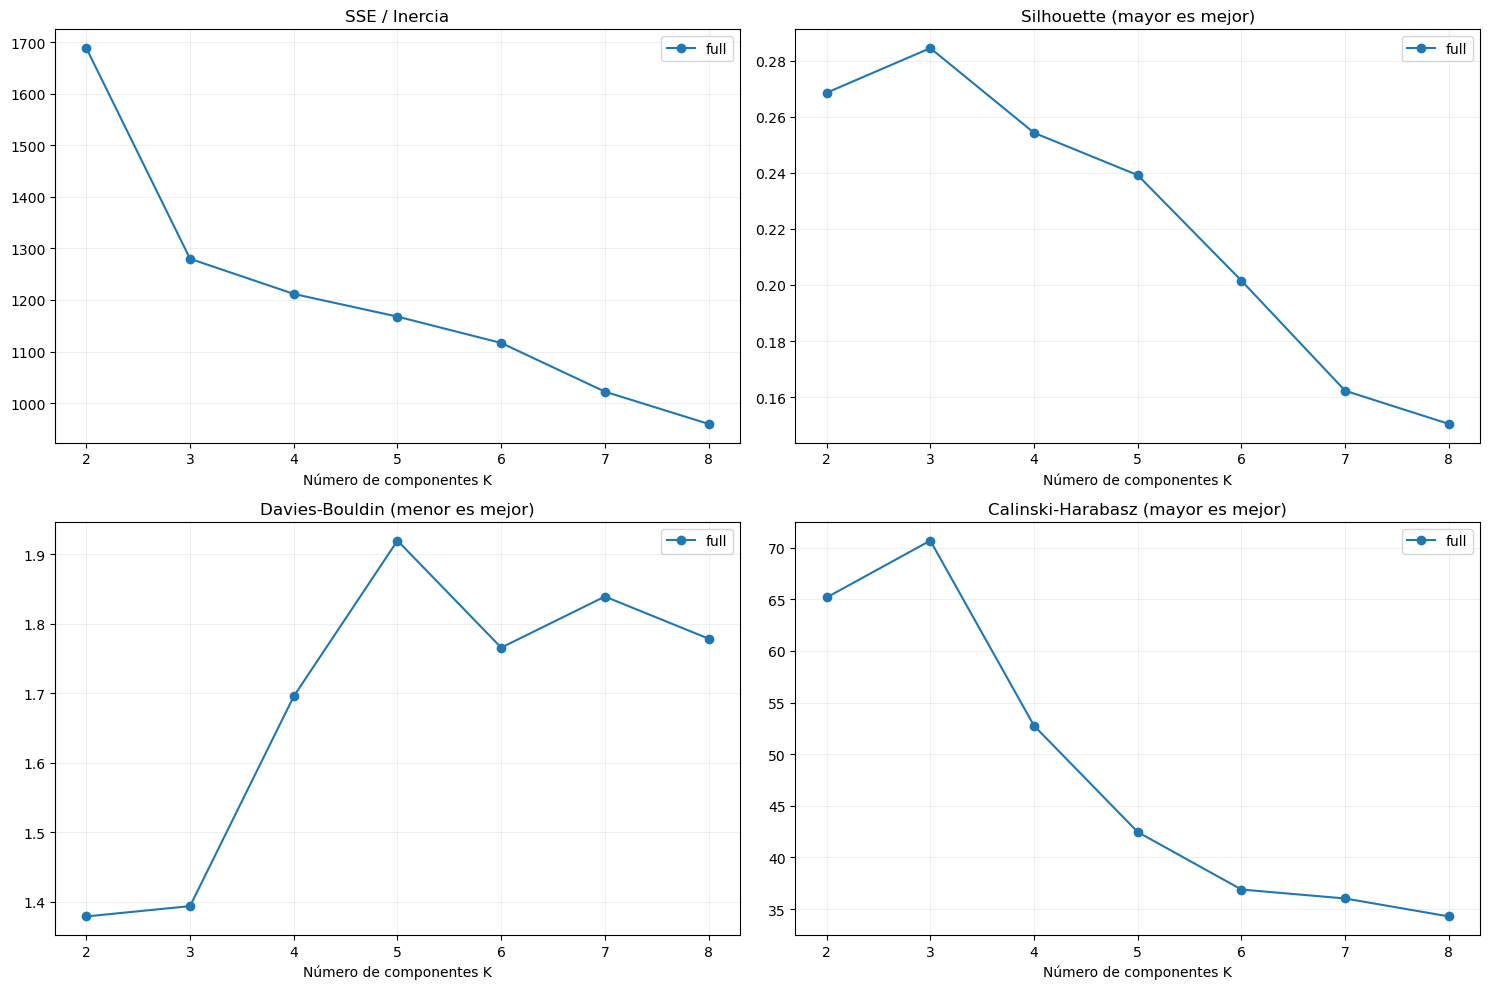

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for cov_type in covariance_types:
    subset = results[results["covariance_type"] == cov_type]
    axes[0, 0].plot(subset["k"], subset["SSE ↓"], marker="o", label=cov_type)
    axes[0, 1].plot(subset["k"], subset["Silhouette ↑"], marker="o", label=cov_type)
    axes[1, 0].plot(subset["k"], subset["Davies-Bouldin ↓"], marker="o", label=cov_type)
    axes[1, 1].plot(subset["k"], subset["Calinski-Harabasz ↑"], marker="o", label=cov_type)

axes[0, 0].set_title("SSE / Inercia")
axes[0, 1].set_title("Silhouette (mayor es mejor)")
axes[1, 0].set_title("Davies-Bouldin (menor es mejor)")
axes[1, 1].set_title("Calinski-Harabasz (mayor es mejor)")
for ax in axes.ravel():
    ax.set_xlabel("Número de componentes K")
    ax.grid(alpha=0.2)
    ax.legend()
plt.tight_layout()
plt.show()

### 6.3. Mejor configuración según ranking

In [13]:
ranking = results.copy()

# Mayor es mejor
ranking["Rank_Silhouette"] = ranking["Silhouette ↑"].rank(
    ascending=False,
    method="min"
)

ranking["Rank_CH"] = ranking["Calinski-Harabasz ↑"].rank(
    ascending=False,
    method="min"
)

# Menor es mejor
ranking["Rank_DB"] = ranking["Davies-Bouldin ↓"].rank(
    ascending=True,
    method="min"
)

ranking["Rank_SSE"] = ranking["SSE ↓"].rank(
    ascending=True,
    method="min"
)

# Suma de posiciones
ranking["Rank_Total"] = (
    ranking["Rank_Silhouette"]
    + ranking["Rank_DB"]
    + ranking["Rank_CH"]
    + ranking["Rank_SSE"]
)

# Ordenar de mejor a peor
ranking = (
    ranking
    .sort_values("Rank_Total", ascending=True)
    .reset_index(drop=True)
)

ranking["Posición"] = ranking.index + 1

ranking[
    [
        "Posición",
        "k",
        "SSE ↓",
        "Silhouette ↑",
        "Davies-Bouldin ↓",
        "Calinski-Harabasz ↑",
        "Rank_Total"
    ]
].round(3)

,Posición,k,SSE ↓,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑,Rank_Total
0,1,3,1279.966,0.284,1.394,70.688,10.0
1,2,2,1688.641,0.269,1.379,65.179,12.0
2,3,4,1211.753,0.254,1.695,52.759,14.0
3,4,6,1116.609,0.202,1.765,36.889,17.0
4,5,5,1167.717,0.239,1.919,42.456,19.0
5,6,7,1022.133,0.162,1.839,36.021,20.0
6,7,8,959.522,0.150,1.778,34.282,20.0


In [14]:
print(models.keys())

dict_keys([('full', 2), ('full', 3), ('full', 4), ('full', 5), ('full', 6), ('full', 7), ('full', 8)])


In [15]:
# Mejor configuración según el ranking
best_row = ranking.iloc[0]

selected_k = int(best_row["k"])

# Recuperar el modelo correspondiente a ese k
selected_gmm = models[("full", selected_k)]

# Etiquetas finales
selected_labels = selected_gmm.predict(X_scaled)

print("K seleccionado:", selected_k)

K seleccionado: 3


## 7. Probabilidades de pertenencia (responsabilidades)

In [21]:
responsibilities = selected_gmm.predict_proba(X_scaled)
responsibilities_df = pd.DataFrame(
    responsibilities,
    columns=[f"P(componente {k})" for k in range(selected_k)]
)
responsibilities_df["cluster_asignado"] = selected_labels
responsibilities_df["probabilidad_maxima"] = responsibilities.max(axis=1)
responsibilities_df.head(50).round(3)

,P(componente 0),P(componente 1),P(componente 2),cluster_asignado,probabilidad_maxima
0,1.000,0.000,0.0,0,1.000
1,1.000,0.000,0.0,0,1.000
2,1.000,0.000,0.0,0,1.000
3,1.000,0.000,0.0,0,1.000
4,1.000,0.000,0.0,0,1.000
5,1.000,0.000,0.0,0,1.000
6,1.000,0.000,0.0,0,1.000
7,1.000,0.000,0.0,0,1.000
8,1.000,0.000,0.0,0,1.000
9,1.000,0.000,0.0,0,1.000


Cada observación recibe una probabilidad para cada componente. La asignación *hard* mostrada por `predict()` corresponde al componente con mayor responsabilidad:

$$\hat z_i=\arg\max_k\gamma_{ik}$$

Una probabilidad máxima cercana a 1 indica una asignación muy definida; valores más bajos sugieren mayor incertidumbre.

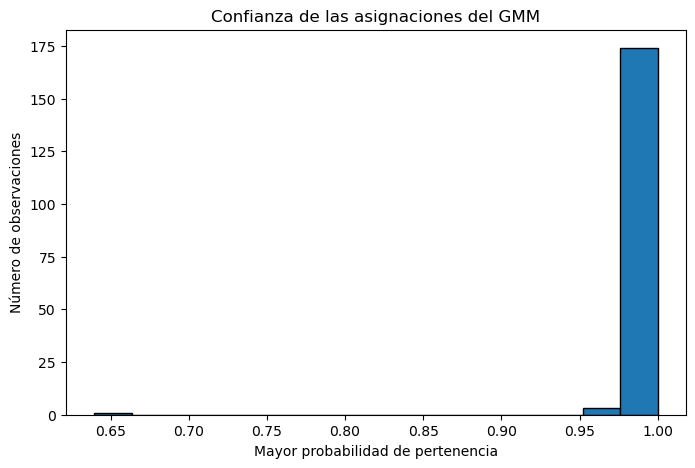

In [17]:
plt.figure(figsize=(8, 5))
plt.hist(responsibilities_df["probabilidad_maxima"], bins=15, edgecolor="black")
plt.xlabel("Mayor probabilidad de pertenencia")
plt.ylabel("Número de observaciones")
plt.title("Confianza de las asignaciones del GMM")
plt.show()

## 8. Visualización de la partición con PCA

El GMM se ajusta utilizando las 13 variables estandarizadas. PCA se utiliza únicamente para proyectar las observaciones a dos dimensiones y visualizar la partición.

In [18]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(
    "Varianza explicada por PC1 + PC2:",
    round(pca.explained_variance_ratio_.sum(), 3)
)

Varianza explicada por PC1 + PC2: 0.554


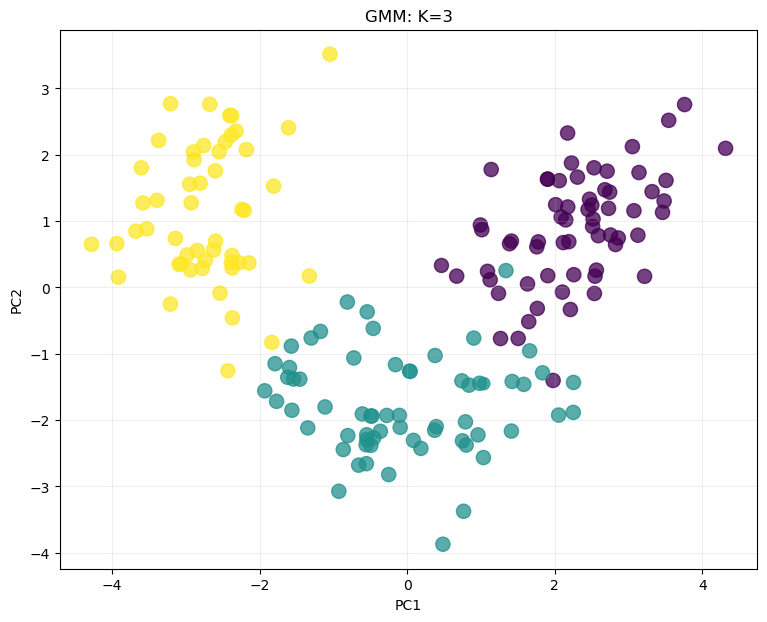

In [22]:
plt.figure(figsize=(9, 7))
plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=selected_labels,
    s=35 + 70 * responsibilities_df["probabilidad_maxima"].to_numpy(),
    alpha=0.75
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"GMM: K={selected_k}")
plt.grid(alpha=0.2)
plt.show()

## 9. Interpretación de los clusters

In [23]:
X_with_cluster = X.copy()
X_with_cluster["cluster"] = selected_labels
cluster_profiles = X_with_cluster.groupby("cluster").mean()
cluster_profiles

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
cluster,,,,,,,,,,,,,
0,13.665714,1.968254,2.434603,17.234921,108.920635,2.811429,2.924603,0.287778,1.945397,5.370952,1.070952,3.140000,1098.682540
1,12.239531,1.925000,2.258750,20.328125,91.562500,2.273906,2.112500,0.362969,1.596563,3.015625,1.057281,2.820781,502.468750
2,13.134118,3.307255,2.417647,21.241176,98.666667,1.683922,0.818824,0.451961,1.145882,7.234706,0.691961,1.696667,619.058824


### 9.1. Perfiles estandarizados

In [24]:
scaled_profiles = (
    pd.DataFrame(X_scaled, columns=X.columns)
    .assign(cluster=selected_labels)
    .groupby("cluster")
    .mean()
)
scaled_profiles.T

cluster,0,1,2
alcohol,0.821570,-0.940144,0.164907
malic_acid,-0.330425,-0.369252,0.871547
ash,0.248879,-0.393925,0.186898
alcalinity_of_ash,-0.678651,0.250192,0.524367
magnesium,0.644493,-0.574280,-0.075473
total_phenols,0.827310,-0.033979,-0.979330
flavanoids,0.898885,0.083560,-1.215248
nonflavanoid_phenols,-0.596891,0.008983,0.726064
proanthocyanins,0.621110,0.009923,-0.779706
color_intensity,0.135335,-0.883509,0.941539


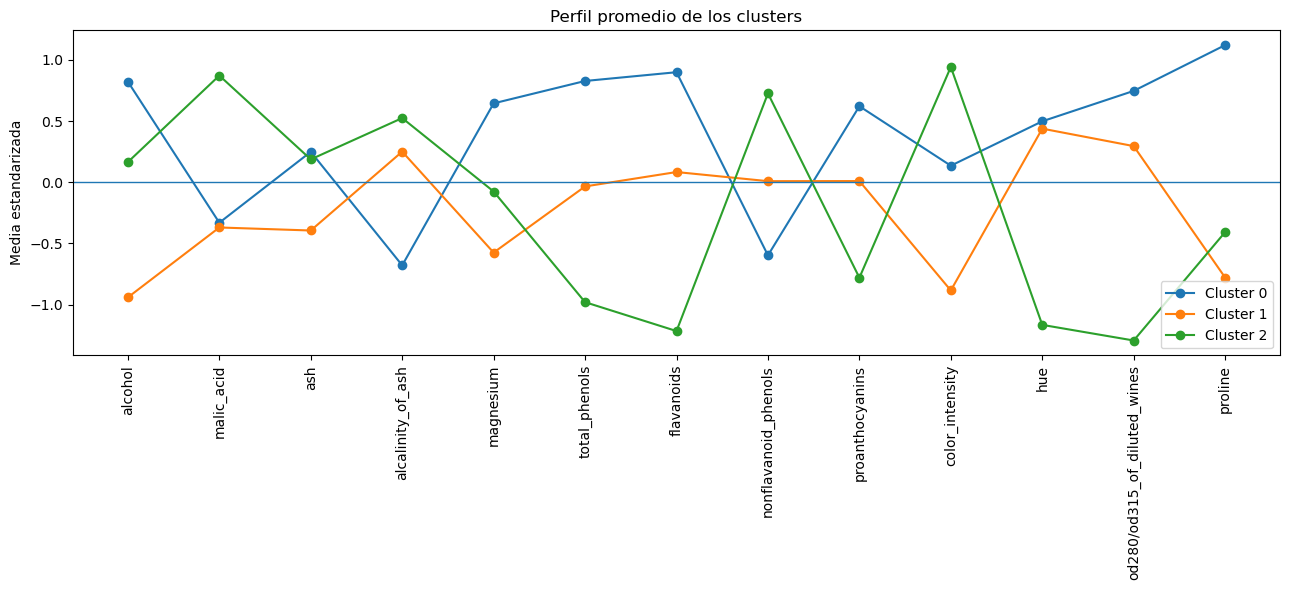

In [25]:
plt.figure(figsize=(13, 6))
for cluster_id in scaled_profiles.index:
    plt.plot(
        scaled_profiles.columns,
        scaled_profiles.loc[cluster_id],
        marker="o",
        label=f"Cluster {cluster_id}"
    )
plt.axhline(0, linewidth=1)
plt.xticks(rotation=90)
plt.ylabel("Media estandarizada")
plt.title("Perfil promedio de los clusters")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Comparación externa con las clases reales

Hasta este punto las clases reales no han participado en el ajuste del GMM. Ahora se utilizan únicamente como referencia externa mediante ARI y NMI.

In [26]:
external_metrics = pd.DataFrame({
    "ARI ↑": [adjusted_rand_score(y, selected_labels)],
    "NMI ↑": [normalized_mutual_info_score(y, selected_labels)]
}, index=["GMM"])
external_metrics.round(3)

,ARI ↑,NMI ↑
GMM,0.88,0.861


## 11. Lectura final

GMM permite modelar clusters con formas elipsoidales y proporciona una asignación probabilística. AIC/BIC ayudan a comparar modelos probabilísticos con distinta complejidad, mientras que Silhouette, Davies-Bouldin y Calinski-Harabasz evalúan la geometría de la partición *hard* derivada de las responsabilidades.